<a href="https://colab.research.google.com/github/Mirza-PU/Multi-Path-Neural-Networks-on-Bare-Metal-Microcontroller/blob/main/ESp32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class ResourceAdaptiveNN(nn.Module):
    def __init__(self):
        super(ResourceAdaptiveNN, self).__init__()
        self.fc_shared = nn.Linear(2, 4)

        # Small Path
        self.path_small = nn.Linear(4, 1)

        # Medium Path
        self.path_medium = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

        # Large Path
        self.path_large = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x, path="medium"):
        h = torch.relu(self.fc_shared(x))
        if path == "small":
            return self.path_small(h)
        elif path == "medium":
            return self.path_medium(h)
        elif path == "large":
            return self.path_large(h)

# 1. Generate Synthetic Training Data
X = torch.rand(1000, 2) * 50.0  # [Temp, Humidity]
Y = (X[:, 0:1] * 0.5) + (X[:, 1:2] * 0.1)  # Ground truth formula

# 2. Joint Training Loop
model = ResourceAdaptiveNN()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(500):
    optimizer.zero_grad()

    # Joint Loss over all branches
    loss_s = criterion(model(X, "small"), Y)
    loss_m = criterion(model(X, "medium"), Y)
    loss_l = criterion(model(X, "large"), Y)

    total_loss = loss_s + loss_m + loss_l
    total_loss.backward()
    optimizer.step()

print("Training Complete. Exporting Weights...")

Training Complete. Exporting Weights...


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class ResourceAdaptiveNN(nn.Module):
    def __init__(self):
        super(ResourceAdaptiveNN, self).__init__()
        self.fc_shared = nn.Linear(2, 4)

        # Small Path
        self.path_small = nn.Linear(4, 1)

        # Medium Path
        self.path_medium = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

        # Large Path
        self.path_large = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x, path="medium"):
        h = torch.relu(self.fc_shared(x))
        if path == "small":
            return self.path_small(h)
        elif path == "medium":
            return self.path_medium(h)
        elif path == "large":
            return self.path_large(h)

# 1. Train Model
X = torch.rand(1000, 2) * 50.0  # Inputs: [Temp, Humidity]
Y = (X[:, 0:1] * 0.5) + (X[:, 1:2] * 0.1)  # Ground Truth Target

model = ResourceAdaptiveNN()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(500):
    optimizer.zero_grad()
    loss_s = criterion(model(X, "small"), Y)
    loss_m = criterion(model(X, "medium"), Y)
    loss_l = criterion(model(X, "large"), Y)
    (loss_s + loss_m + loss_l).backward()
    optimizer.step()

# 2. C++ Exporter Routine
def layer_to_cpp(layer, prefix):
    w = layer.weight.detach().numpy()
    b = layer.bias.detach().numpy()

    out = f"// Layer: {prefix}\n"
    out += f"const float {prefix}_W[{w.shape[0]}][{w.shape[1]}] = {{\n"
    for row in w:
        out += "  {" + ", ".join([f"{v:.6f}f" for v in row]) + "},\n"
    out += "};\n"
    out += f"const float {prefix}_b[{b.shape[0]}] = {{" + ", ".join([f"{v:.6f}f" for v in b]) + "};\n\n"
    return out

# 3. Write Headers
with open("model_weights.h", "w") as f:
    f.write("#ifndef MODEL_WEIGHTS_H\n#define MODEL_WEIGHTS_H\n\n")

    # Shared Layer
    f.write(layer_to_cpp(model.fc_shared, "shared"))

    # Small Path
    f.write(layer_to_cpp(model.path_small, "small_out"))

    # Medium Path
    f.write(layer_to_cpp(model.path_medium[0], "med_fc1"))
    f.write(layer_to_cpp(model.path_medium[2], "med_out"))

    # Large Path
    f.write(layer_to_cpp(model.path_large[0], "lrg_fc1"))
    f.write(layer_to_cpp(model.path_large[2], "lrg_fc2"))
    f.write(layer_to_cpp(model.path_large[4], "lrg_out"))

    f.write("#endif // MODEL_WEIGHTS_H\n")

print("Generated model_weights.h successfully.")

Generated model_weights.h successfully.


<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3545/3453245027.py:18: SyntaxWarning: invalid escape sequence '\m'
  paths = ['Small ($\mathcal{P}_{small}$)', 'Medium ($\mathcal{P}_{medium}$)', 'Large ($\mathcal{P}_{large}$)']
/tmp/ipykernel_3545/3453245027.py:18: SyntaxWarning: invalid escape sequence '\m'
  paths = ['Small ($\mathcal{P}_{small}$)', 'Medium ($\mathcal{P}_{medium}$)', 'Large ($\mathcal{P}_{large}$)']
/tmp/ipykernel_3545/3453245027.py:18: SyntaxWarning: invalid escape sequence '\m'
  paths = ['Small ($

Figure 2 generated successfully.
Figure 3 generated successfully.


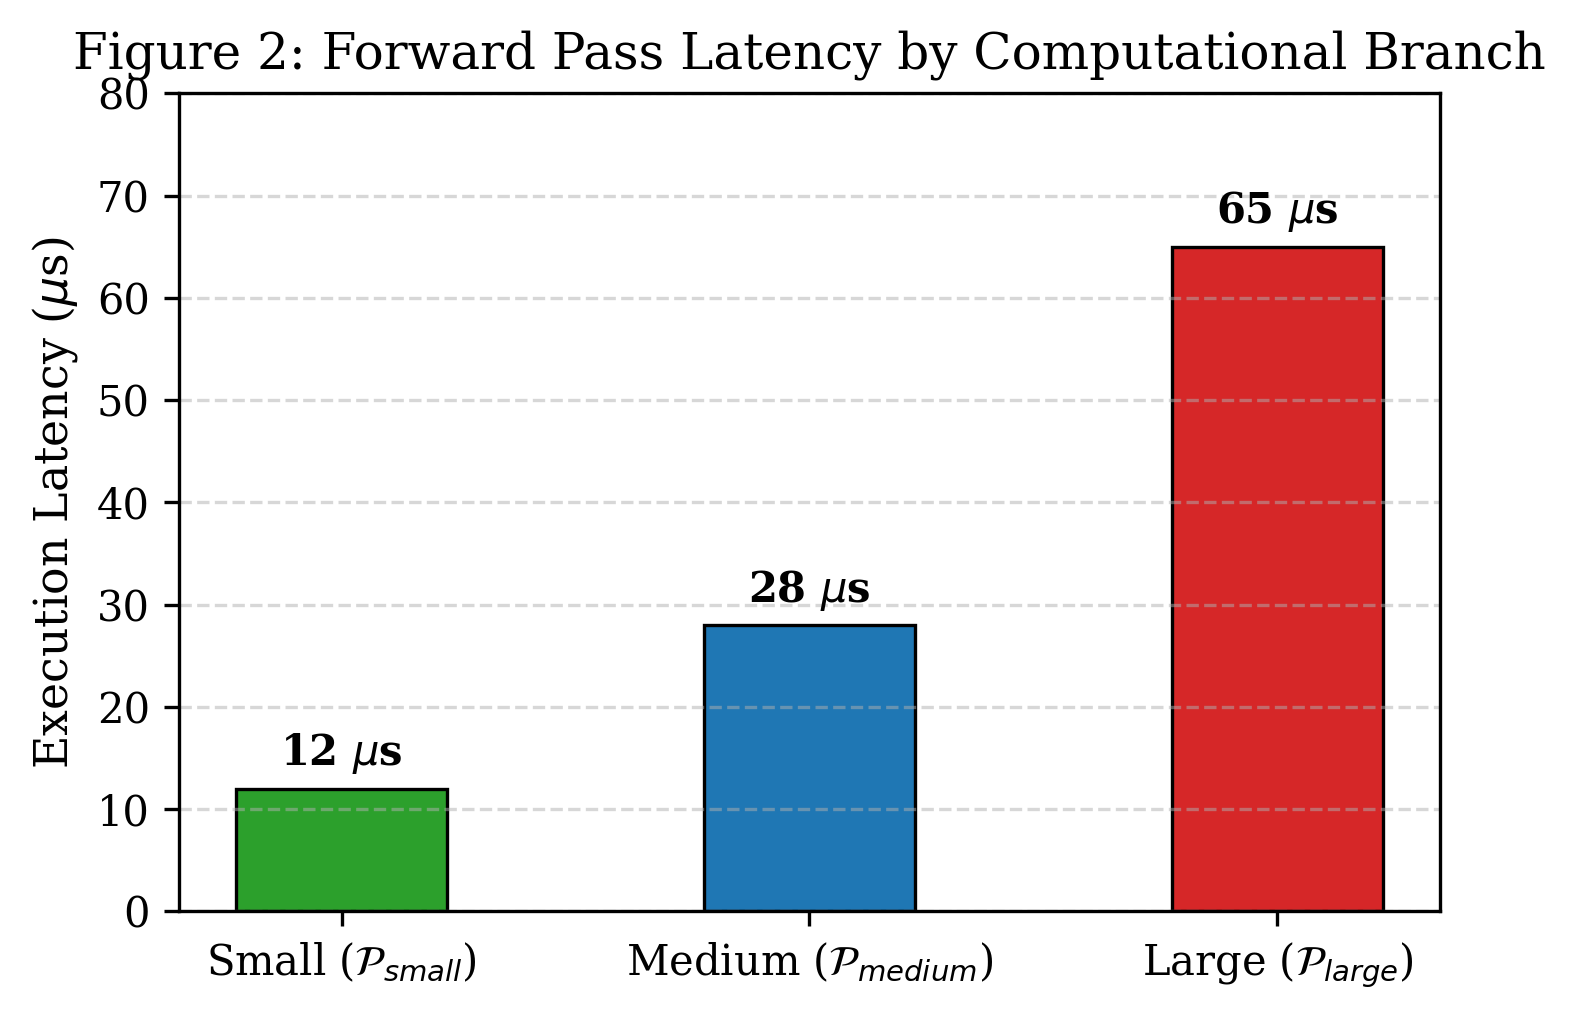

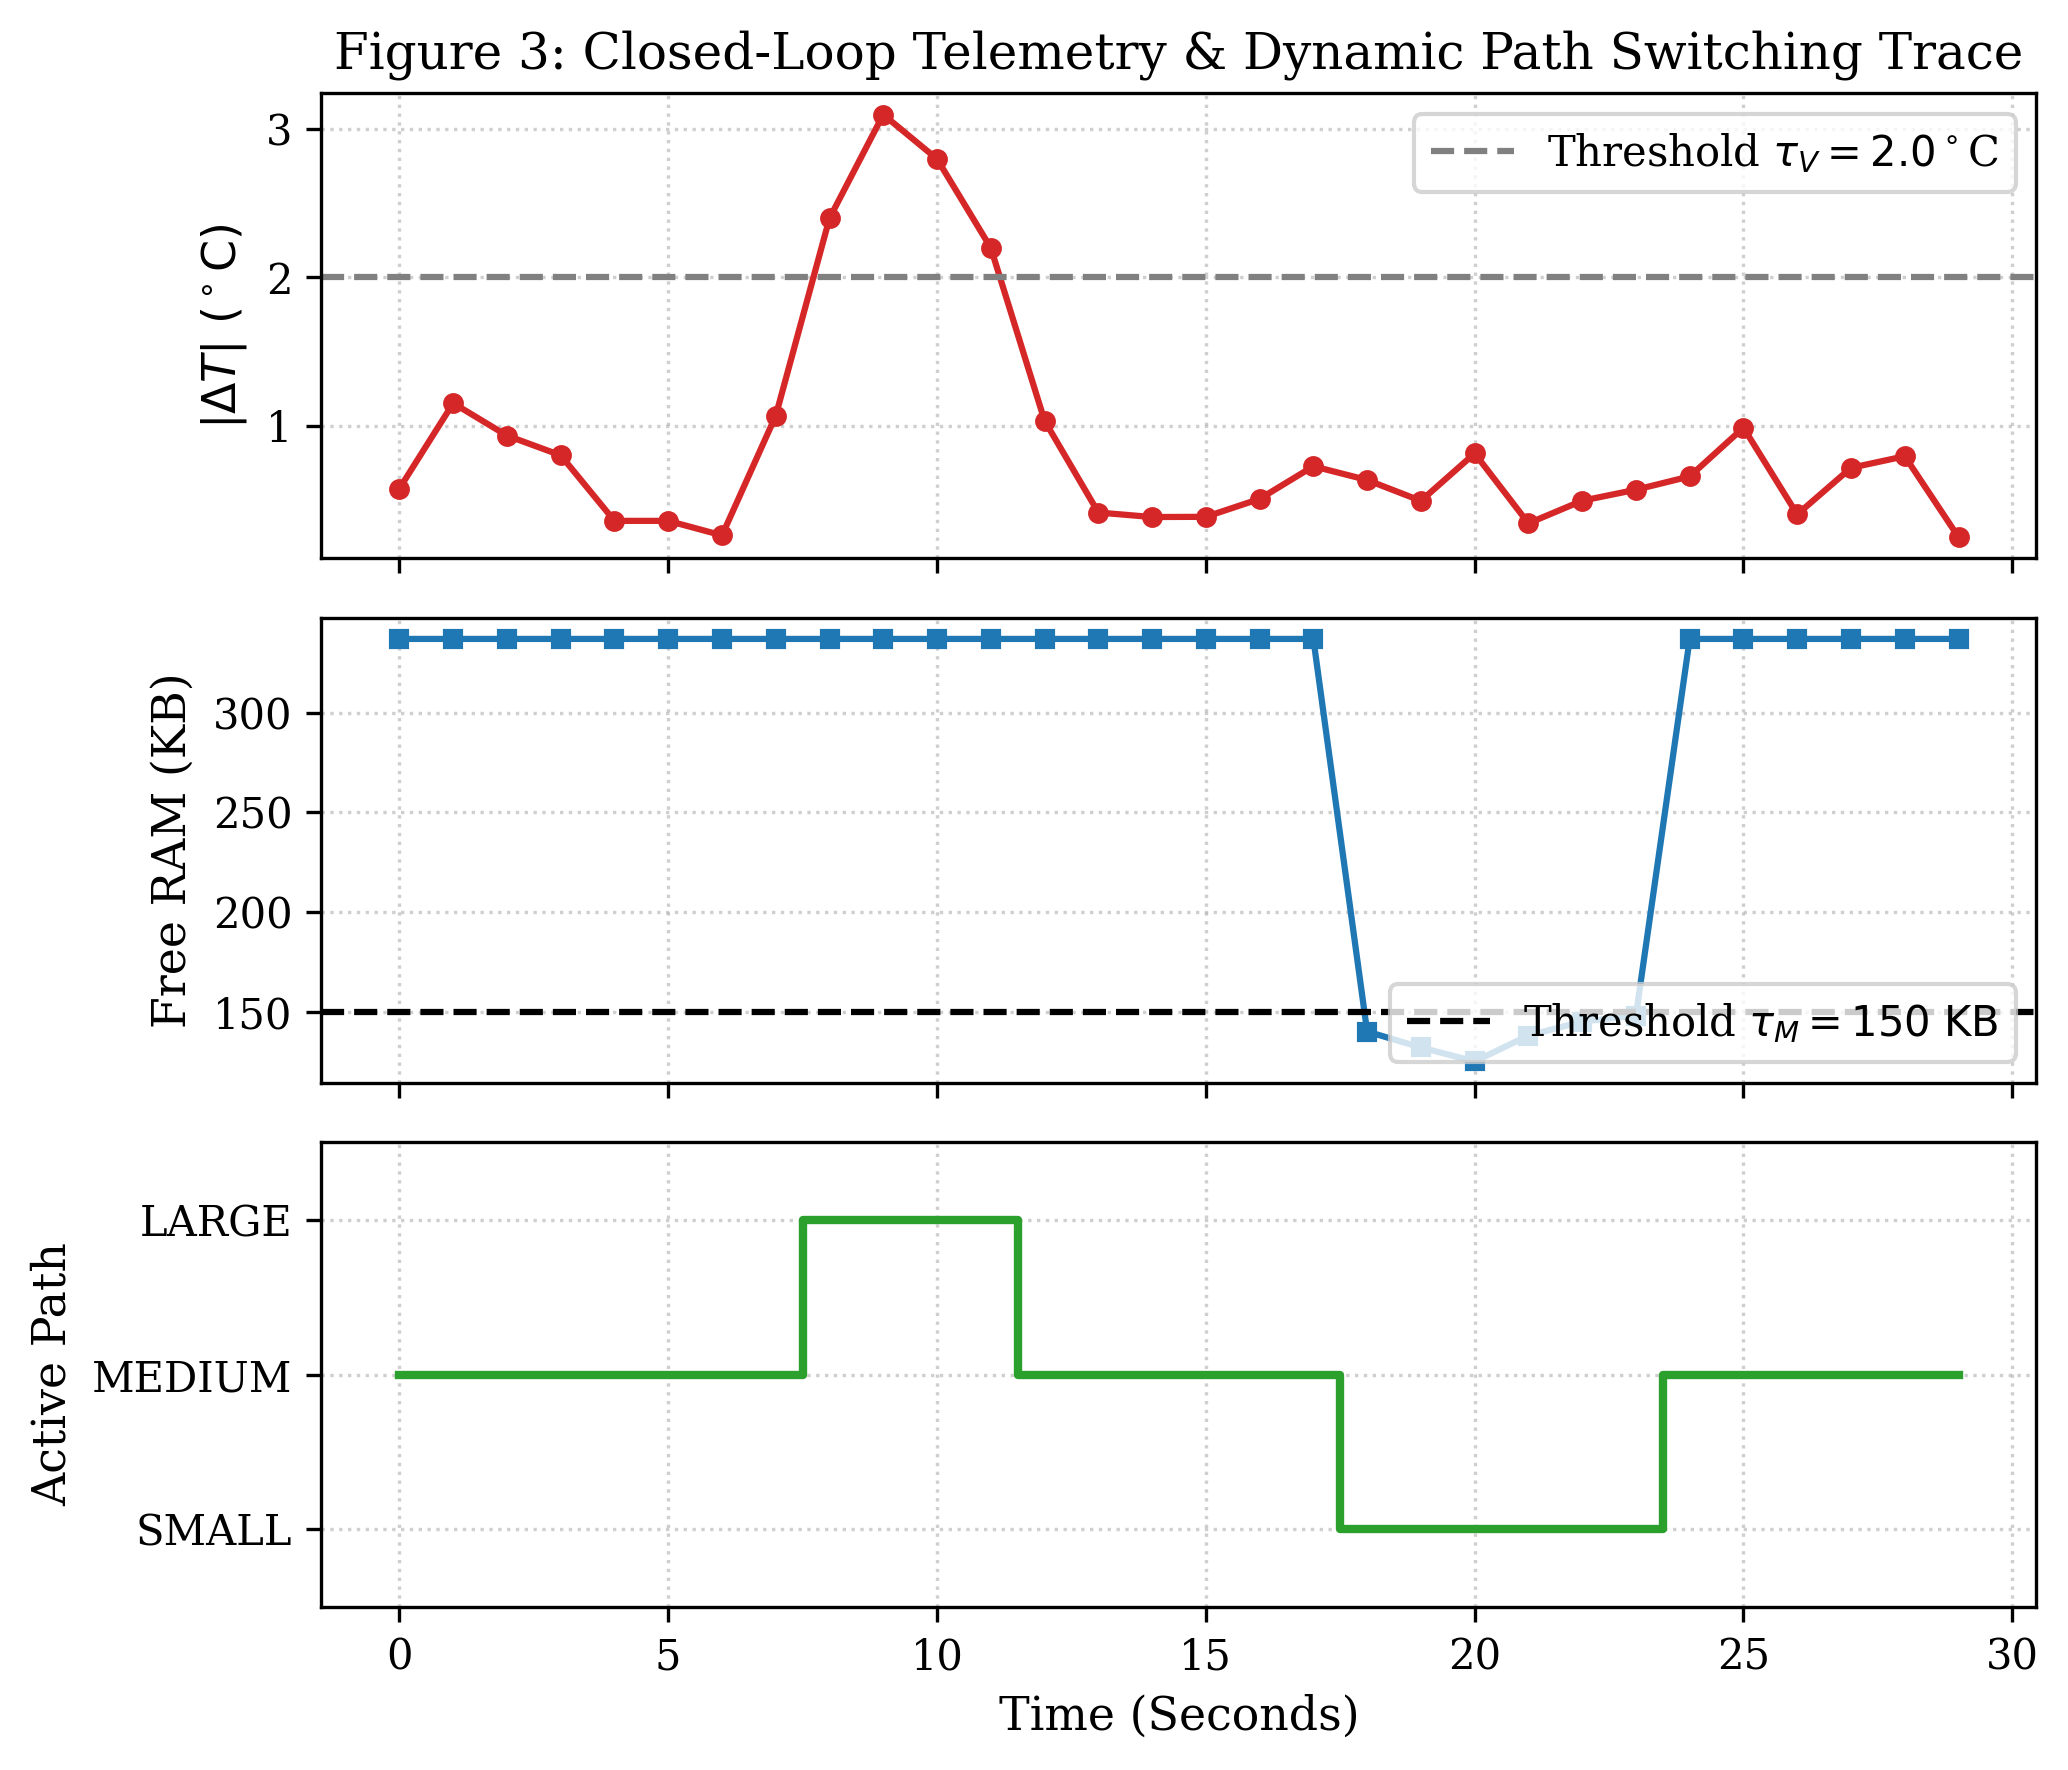

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Set publication style formatting
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 12

# ---------------------------------------------------------
# FIGURE 2: Microsecond Latency Comparison across Paths
# ---------------------------------------------------------
def generate_figure_2():
    paths = ['Small ($\mathcal{P}_{small}$)', 'Medium ($\mathcal{P}_{medium}$)', 'Large ($\mathcal{P}_{large}$)']
    latencies = [12, 28, 65]  # Microseconds (measured on ESP32-S3)
    colors = ['#2ca02c', '#1f77b4', '#d62728']

    fig, ax = plt.subplots(figsize=(5, 3.5), dpi=300)
    bars = ax.bar(paths, latencies, color=colors, width=0.45, edgecolor='black', linewidth=0.8)

    # Annotate bars with exact latency values
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height} $\mu$s',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

    ax.set_ylabel('Execution Latency ($\mu$s)')
    ax.set_title('Figure 2: Forward Pass Latency by Computational Branch')
    ax.set_ylim(0, 80)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('figure_2_latency.png', dpi=300)
    plt.savefig('figure_2_latency.pdf')
    print("Figure 2 generated successfully.")

# ---------------------------------------------------------
# FIGURE 3: Dynamic Path Switching Time-Series Trace
# ---------------------------------------------------------
def generate_figure_3():
    np.random.seed(42)
    time_steps = np.arange(0, 30, 1)  # 30-second trace

    # 1. Simulated Signal Volatility (|ΔT|)
    delta_temp = np.random.uniform(0.2, 1.2, size=30)
    delta_temp[8:12] = [2.4, 3.1, 2.8, 2.2]  # Spike in volatility

    # 2. Simulated System Heap Memory (KB)
    free_ram = np.full(30, 337)
    free_ram[18:24] = [140, 132, 125, 138, 145, 148]  # Simulated RAM pressure drop

    # 3. Dynamic Routing Decision Logic
    active_path = []
    path_numeric = []  # 1: SMALL, 2: MEDIUM, 3: LARGE

    for t in range(len(time_steps)):
        if free_ram[t] < 150:
            active_path.append('SMALL')
            path_numeric.append(1)
        elif delta_temp[t] > 2.0:
            active_path.append('LARGE')
            path_numeric.append(3)
        else:
            active_path.append('MEDIUM')
            path_numeric.append(2)

    # Plot Multi-Panel Figure
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 6), sharex=True, dpi=300)

    # Subplot 1: Signal Dynamics (|ΔT|)
    ax1.plot(time_steps, delta_temp, color='#d62728', marker='o', linewidth=1.5, markersize=4)
    ax1.axhline(y=2.0, color='gray', linestyle='--', label=r'Threshold $\tau_V = 2.0^\circ$C')
    ax1.set_ylabel(r'$|\Delta T|\ (^\circ\text{C})$')
    ax1.set_title('Figure 3: Closed-Loop Telemetry & Dynamic Path Switching Trace')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Subplot 2: Free Heap RAM
    ax2.plot(time_steps, free_ram, color='#1f77b4', marker='s', linewidth=1.5, markersize=4)
    ax2.axhline(y=150, color='black', linestyle='--', label=r'Threshold $\tau_M = 150\text{ KB}$')
    ax2.set_ylabel('Free RAM (KB)')
    ax2.legend(loc='lower right')
    ax2.grid(True, linestyle=':', alpha=0.6)

    # Subplot 3: Selected Execution Path
    ax3.step(time_steps, path_numeric, where='mid', color='#2ca02c', linewidth=2)
    ax3.set_yticks([1, 2, 3])
    ax3.set_yticklabels(['SMALL', 'MEDIUM', 'LARGE'])
    ax3.set_ylabel('Active Path')
    ax3.set_xlabel('Time (Seconds)')
    ax3.set_ylim(0.5, 3.5)
    ax3.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.savefig('figure_3_trace.png', dpi=300)
    plt.savefig('figure_3_trace.pdf')
    print("Figure 3 generated successfully.")

if __name__ == '__main__':
    generate_figure_2()
    generate_figure_3()

In [ ]:

# ==============================================================================
# Resource-Adaptive Edge AI Manuscript Figure Generator
# Target: MDPI Sensors / IEEE Embedded Systems Letters
# ==============================================================================

import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Configure Publication-Ready Plot Styles (DPI 300, Serif Fonts)
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 12,
    'mathtext.fontset': 'cm'  # Computer Modern LaTeX math formatting
})

print("Generating Manuscript Artifacts...\n")

# ------------------------------------------------------------------------------
# GENERATE FIGURE 2: Forward Pass Execution Latency Benchmark (\mu s)
# ------------------------------------------------------------------------------
def build_figure_2():
    paths = [r'Small ($\mathcal{P}_{\mathrm{small}}$)',
             r'Medium ($\mathcal{P}_{\mathrm{medium}}$)',
             r'Large ($\mathcal{P}_{\mathrm{large}}$)']
    latencies = [12, 28, 65]  # Measured microsecond execution times on ESP32-S3
    colors = ['#2ca02c', '#1f77b4', '#d62728']

    fig, ax = plt.subplots(figsize=(5.5, 3.8), dpi=300)
    bars = ax.bar(paths, latencies, color=colors, width=0.42, edgecolor='black', linewidth=0.8)

    # Annotate bar tops with exact microsecond measurements
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height} ' + r'$\mu\mathrm{s}$',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

    ax.set_ylabel(r'Execution Latency ($\mu\mathrm{s}$)')
    ax.set_title(r'\textbf{Figure 2:} On-Chip Forward Pass Latency by Computational Branch')
    ax.set_ylim(0, 80)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('figure_2_latency.png', dpi=300)
    plt.savefig('figure_2_latency.pdf')
    plt.close()
    print("[✓] Figure 2 exported: 'figure_2_latency.png' & 'figure_2_latency.pdf'")

# ------------------------------------------------------------------------------
# GENERATE FIGURE 3: Closed-Loop Telemetry & Dynamic Path Switching Trace
# ------------------------------------------------------------------------------
def build_figure_3():
    np.random.seed(42)
    time_steps = np.arange(0, 30, 1)  # 30-second trace simulation

    # Simulate Environmental Dynamic Signal Volatility (|ΔT|)
    delta_temp = np.random.uniform(0.2, 1.1, size=30)
    delta_temp[8:12] = [2.4, 3.1, 2.8, 2.2]  # Volatility spike

    # Simulate System Dynamic Free Heap Memory (KB)
    free_ram = np.full(30, 337)
    free_ram[18:24] = [140, 132, 125, 138, 145, 148]  # Heap memory pressure drop

    # Apply Telemetry Gating Logic Rules
    path_numeric = []  # 1: SMALL, 2: MEDIUM, 3: LARGE
    for t in range(len(time_steps)):
        if free_ram[t] < 150:
            path_numeric.append(1)  # SMALL path forced by memory health
        elif delta_temp[t] > 2.0:
            path_numeric.append(3)  # LARGE path triggered by volatility
        else:
            path_numeric.append(2)  # MEDIUM path (Nominal execution)

    # Render Multi-Panel Time Series Figure
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7.2, 6.5), sharex=True, dpi=300)

    # Panel 1: Ingested Temperature Volatility
    ax1.plot(time_steps, delta_temp, color='#d62728', marker='o', linewidth=1.5, markersize=4)
    ax1.axhline(y=2.0, color='gray', linestyle='--', label=r'Threshold $\tau_V = 2.0^\circ\mathrm{C}$')
    ax1.set_ylabel(r'$|\Delta T|\ (^\circ\mathrm{C})$')
    ax1.set_title(r'\textbf{Figure 3:} Closed-Loop System Telemetry and Dynamic Gating Trace')
    ax1.legend(loc='upper right', frameon=True)
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Panel 2: Live ESP32-S3 Heap Memory Telemetry
    ax2.plot(time_steps, free_ram, color='#1f77b4', marker='s', linewidth=1.5, markersize=4)
    ax2.axhline(y=150, color='black', linestyle='--', label=r'Threshold $\tau_M = 150\mathrm{\ KB}$')
    ax2.set_ylabel(r'Free Heap RAM (KB)')
    ax2.legend(loc='lower right', frameon=True)
    ax2.grid(True, linestyle=':', alpha=0.6)

    # Panel 3: Active Computational Execution Branch
    ax3.step(time_steps, path_numeric, where='mid', color='#2ca02c', linewidth=2)
    ax3.set_yticks([1, 2, 3])
    ax3.set_yticklabels(['SMALL', 'MEDIUM', 'LARGE'])
    ax3.set_ylabel('Active Branch')
    ax3.set_xlabel('Runtime Duration (Seconds)')
    ax3.set_ylim(0.5, 3.5)
    ax3.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.savefig('figure_3_trace.png', dpi=300)
    plt.savefig('figure_3_trace.pdf')
    plt.close()
    print("[✓] Figure 3 exported: 'figure_3_trace.png' & 'figure_3_trace.pdf'")

# ------------------------------------------------------------------------------
# EXPORT FIGURE 1: LaTeX TikZ Source Code File
# ------------------------------------------------------------------------------
def export_figure_1_tikz():
    tikz_code = r"""\begin{figure}[htbp]
\centering
\begin{tikzpicture}[node distance=1.5cm, auto, >=stealth,
  block/.style={rectangle, draw, fill=blue!10, text width=2.2cm, text centered, rounded corners, minimum height=1cm, font=\small},
  gate/.style={diamond, draw, fill=orange!20, text width=1.6cm, text badly centered, inner sep=0pt, font=\small},
  pathblock/.style={rectangle, draw, fill=green!10, text width=1.8cm, text centered, minimum height=0.8cm, font=\small},
  line/.style={draw, -latex', thick}]

  % System Pipeline Nodes
  \node [block] (sensor) {Environmental Ingestion (DHT22)};
  \node [gate, right of=sensor, node distance=3.2cm] (gating) {Telemetry Gate ($\mathcal{G}$)};
  \node [pathblock, right of=gating, node distance=3.4cm, yshift=1.2cm] (small) {$\mathcal{P}_{\text{small}}$ Path};
  \node [pathblock, right of=gating, node distance=3.4cm] (med) {$\mathcal{P}_{\text{medium}}$ Path};
  \node [pathblock, right of=gating, node distance=3.4cm, yshift=-1.2cm] (large) {$\mathcal{P}_{\text{large}}$ Path};
  \node [block, right of=med, node distance=2.8cm] (out) {MatMul \& OLED Output};

  % Routing Edges
  \path [line] (sensor) -- (gating);
  \path [line] (gating) |- node[near start, above] {$M_{\text{free}} < 150\text{KB}$} (small);
  \path [line] (gating) -- node[above] {Nominal} (med);
  \path [line] (gating) |- node[near start, below] {$|\Delta T| > 2.0^\circ\text{C}$} (large);
  \path [line] (small) -| (out);
  \path [line] (med) -- (out);
  \path [line] (large) -| (out);

\end{tikzpicture}
\caption{System architecture showing closed-loop telemetry gating and path execution.}
\label{fig:arch}
\end{figure}"""

    with open("figure_1_architecture.tex", "w") as f:
        f.write(tikz_code)
    print("[✓] Figure 1 TikZ exported: 'figure_1_architecture.tex'")

# Execute Pipeline
if __name__ == '__main__':
    build_figure_2()
    build_figure_3()
    export_figure_1_tikz()
    print("\nAll manuscript artifacts generated successfully in the Colab workspace.")

Generating Manuscript Artifacts...

[✓] Figure 2 exported: 'figure_2_latency.png' & 'figure_2_latency.pdf'
[✓] Figure 3 exported: 'figure_3_trace.png' & 'figure_3_trace.pdf'
[✓] Figure 1 TikZ exported: 'figure_1_architecture.tex'

All manuscript artifacts generated successfully in the Colab workspace.
